In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers==4.35.0
!pip install torch torchvision
!pip install nltk scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 125.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 31.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.20.1
    Uninstalling huggingface_hub-1.20.1:
      Successfully uninstalled huggingface_hub-1.20.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the

In [ ]:
import os

# Base project path on your Google Drive
BASE_PATH = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"

# Dataset paths
FAKE_CSV   = os.path.join(BASE_PATH, "datasets/fake_news/Fake.csv")
TRUE_CSV   = os.path.join(BASE_PATH, "datasets/fake_news/True.csv")

# Output paths
MODEL_SAVE_PATH  = os.path.join(BASE_PATH, "models/bert_model")
GRAPHS_SAVE_PATH = os.path.join(BASE_PATH, "outputs/graphs")

# Create folders if they don't exist
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(GRAPHS_SAVE_PATH, exist_ok=True)

print("All paths configured!")
print(f"   Fake CSV  : {FAKE_CSV}")
print(f"   True CSV  : {TRUE_CSV}")
print(f"   Model save: {MODEL_SAVE_PATH}")
print(f"   Graphs    : {GRAPHS_SAVE_PATH}")

All paths configured!
   Fake CSV  : /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/datasets/fake_news/Fake.csv
   True CSV  : /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/datasets/fake_news/True.csv
   Model save: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/bert_model
   Graphs    : /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/outputs/graphs


In [ ]:
import os

for path in [FAKE_CSV, TRUE_CSV]:
    if os.path.exists(path):
        size = os.path.getsize(path) / (1024*1024)
        print(f"Found: {path}  ({size:.1f} MB)")
    else:
        print(f" NOT FOUND: {path}")
        print("Check your Google Drive folder structure!")

Found: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/datasets/fake_news/Fake.csv  (59.9 MB)
Found: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/datasets/fake_news/True.csv  (51.1 MB)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import string
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" All libraries imported!")
print(f"  Device: {device}")
print(f" GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Not available — go to Runtime > Change runtime type > T4 GPU'}")

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading packag

 All libraries imported!
  Device: cuda
 GPU: Tesla T4


In [ ]:
# Load datasets
fake_df = pd.read_csv(FAKE_CSV)
true_df = pd.read_csv(TRUE_CSV)

print("=" * 50)
print("FAKE NEWS DATASET")
print("=" * 50)
print(f"Shape     : {fake_df.shape}")
print(f"Columns   : {list(fake_df.columns)}")
print(f"Null vals : {fake_df.isnull().sum().to_dict()}")
print("\nSample rows:")
display(fake_df.head(3))

print("\n" + "=" * 50)
print("TRUE NEWS DATASET")
print("=" * 50)
print(f"Shape     : {true_df.shape}")
print(f"Columns   : {list(true_df.columns)}")
print(f"Null vals : {true_df.isnull().sum().to_dict()}")
print("\nSample rows:")
display(true_df.head(3))

FAKE NEWS DATASET
Shape     : (23481, 4)
Columns   : ['title', 'text', 'subject', 'date']
Null vals : {'title': 0, 'text': 0, 'subject': 0, 'date': 0}

Sample rows:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"



TRUE NEWS DATASET
Shape     : (21417, 4)
Columns   : ['title', 'text', 'subject', 'date']
Null vals : {'title': 0, 'text': 0, 'subject': 0, 'date': 0}

Sample rows:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"


In [ ]:
# Add labels: 1 = Fake, 0 = Real
fake_df['label'] = 1
true_df['label'] = 0

# Combine title + text into one column for richer context
fake_df['content'] = fake_df['title'].fillna('') + ' ' + fake_df['text'].fillna('')
true_df['content'] = true_df['title'].fillna('') + ' ' + true_df['text'].fillna('')

# Merge and shuffle
df = pd.concat([fake_df[['content', 'label']],
                true_df[['content', 'label']]], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Drop empty rows
df = df[df['content'].str.strip() != ''].reset_index(drop=True)

print(f" Merged dataset shape : {df.shape}")
print(f"\n Label distribution:")
print(df['label'].value_counts().rename({1: 'Fake', 0: 'Real'}))
print(f"\nFake %: {df['label'].mean()*100:.1f}%")
print(f"Real %: {(1 - df['label'].mean())*100:.1f}%")
display(df.head(5))

 Merged dataset shape : (44898, 2)

 Label distribution:
label
Fake    23481
Real    21417
Name: count, dtype: int64

Fake %: 52.3%
Real %: 47.7%


,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,1
1,Trump drops Steve Bannon from National Securit...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,0
3,OOPS: Trump Just Accidentally Confirmed He Le...,1
4,Donald Trump heads for Scotland to reopen a go...,0


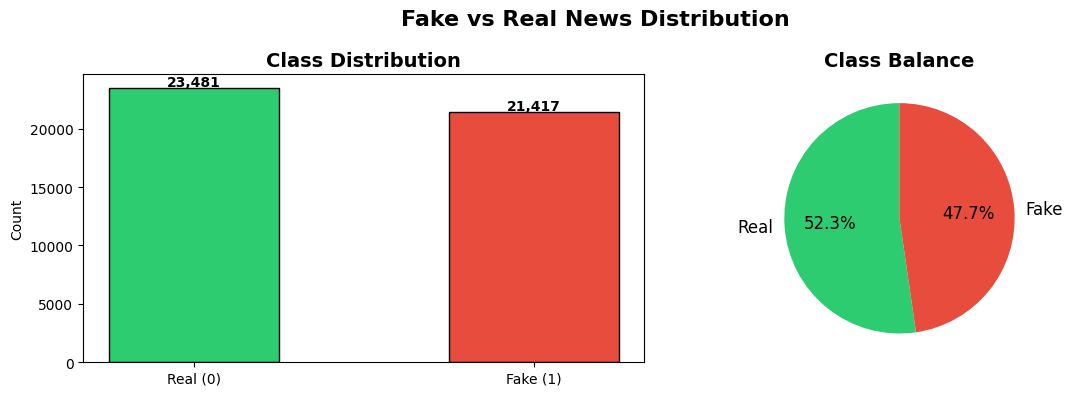

Graph saved to Drive!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Bar chart
counts = df['label'].value_counts()
axes[0].bar(['Real (0)', 'Fake (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Pie chart
axes[1].pie(counts.values, labels=['Real', 'Fake'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Class Balance', fontsize=14, fontweight='bold')

plt.suptitle('Fake vs Real News Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAPHS_SAVE_PATH}/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved to Drive!")

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Full NLP preprocessing pipeline:
    lowercase → remove URLs → remove HTML → remove punctuation
    → remove numbers → remove stopwords → strip whitespace
    """
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenize and remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    return ' '.join(tokens)

print("Cleaning text...")
df['cleaned_content'] = df['content'].apply(clean_text)

# Drop rows where cleaning left empty string
df = df[df['cleaned_content'].str.strip() != ''].reset_index(drop=True)

print(f"Text cleaning complete!")
print(f"   Rows remaining: {len(df):,}")
print(f"\n Example — BEFORE cleaning:\n{df['content'].iloc[0][:300]}")
print(f"\n Example — AFTER cleaning:\n{df['cleaned_content'].iloc[0][:300]}")

Cleaning text...
Text cleaning complete!
   Rows remaining: 44,889

 Example — BEFORE cleaning:
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements 

 Example — AFTER cleaning:
ben stein calls circuit court committed ‘coup d’état’ constitution century wire says ben stein reputable professor pepperdine university also hollywood fame appearing shows films ferris bueller day made provocative statements judge jeanine pirro show recently discussing halt imposed president trump 


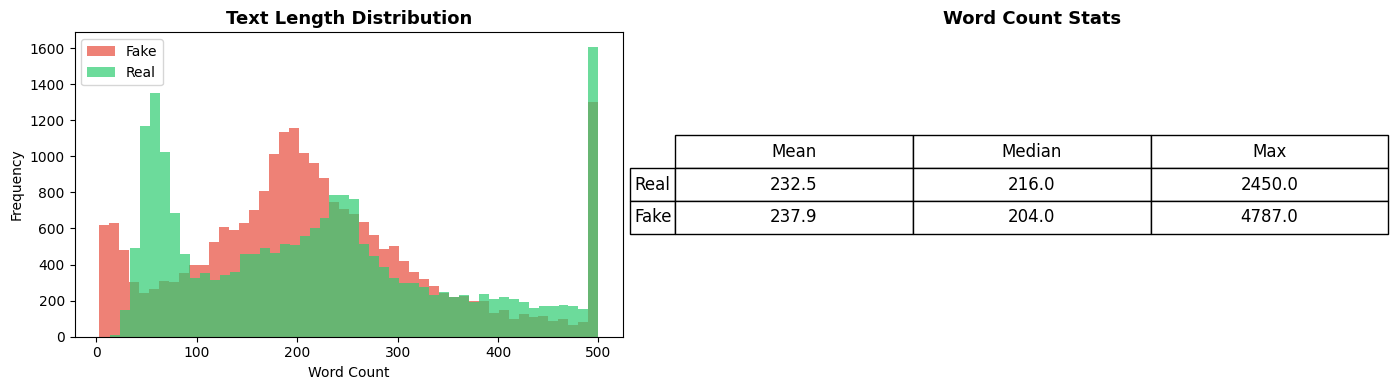

Graph saved to Drive!


In [ ]:
df['text_length'] = df['cleaned_content'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Fake news length distribution
fake_lengths = df[df['label']==1]['text_length']
real_lengths  = df[df['label']==0]['text_length']

axes[0].hist(fake_lengths.clip(upper=500), bins=50,
             color='#e74c3c', alpha=0.7, label='Fake')
axes[0].hist(real_lengths.clip(upper=500),  bins=50,
             color='#2ecc71', alpha=0.7, label='Real')
axes[0].set_title('Text Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Stats table
stats = df.groupby('label')['text_length'].describe()[['mean','50%','max']]
stats.index = ['Real', 'Fake']
axes[1].axis('off')
table = axes[1].table(cellText=stats.round(1).values,
                       rowLabels=stats.index,
                       colLabels=['Mean', 'Median', 'Max'],
                       loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 2)
axes[1].set_title('Word Count Stats', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{GRAPHS_SAVE_PATH}/text_length_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved to Drive!")

In [ ]:
# For BERT, we truncate to 128 tokens max
# Use a balanced sample of 30,000 rows
MAX_SAMPLES = 30000
MAX_LEN     = 128
BATCH_SIZE  = 16

df_sample = df.sample(n=min(MAX_SAMPLES, len(df)),
                      random_state=42).reset_index(drop=True)

# 80% train | 10% val | 10% test
X = df_sample['cleaned_content'].values
y = df_sample['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Data split complete!")
print(f"   Train size : {len(X_train):,}  | Fake: {y_train.sum():,} | Real: {(y_train==0).sum():,}")
print(f"   Val size   : {len(X_val):,}   | Fake: {y_val.sum():,}  | Real: {(y_val==0).sum():,}")
print(f"   Test size  : {len(X_test):,}   | Fake: {y_test.sum():,}  | Real: {(y_test==0).sum():,}")

Data split complete!
   Train size : 24,000  | Fake: 12,528 | Real: 11,472
   Val size   : 3,000   | Fake: 1,566  | Real: 1,434
   Test size  : 3,000   | Fake: 1,566  | Real: 1,434


In [ ]:
print("Loading BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("Tokenizer loaded!")

# Quick test
sample = X_train[0]
tokens = tokenizer(sample, max_length=MAX_LEN,
                   truncation=True, padding='max_length',
                   return_tensors='pt')

print(f"\nSample text (first 100 chars): {sample[:100]}")
print(f"   input_ids shape    : {tokens['input_ids'].shape}")
print(f"   attention_mask shape: {tokens['attention_mask'].shape}")

Loading BERT tokenizer...


Tokenizer loaded!

Sample text (first 100 chars): support irish pms party falls snap election nears dublin reuters support ireland governing fine gael
   input_ids shape    : torch.Size([1, 128])
   attention_mask shape: torch.Size([1, 128])


In [ ]:
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length     = self.max_len,
            truncation     = True,
            padding        = 'max_length',
            return_tensors = 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = FakeNewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = FakeNewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = FakeNewsDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("Datasets and DataLoaders created!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

Datasets and DataLoaders created!
   Train batches : 1500
   Val batches   : 188
   Test batches  : 188


In [ ]:
print("Loading BERT model (bert-base-uncased)...")

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2           # Binary: Fake or Real
)
model = model.to(device)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"BERT model loaded and moved to {device}!")
print(f"   Total parameters    : {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")

Loading BERT model (bert-base-uncased)...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT model loaded and moved to cuda!
   Total parameters    : 109,483,778
   Trainable parameters: 109,483,778


In [ ]:
EPOCHS       = 3
LEARNING_RATE = 2e-5
WARMUP_STEPS  = 0

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, eps=1e-8)

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = WARMUP_STEPS,
    num_training_steps = total_steps
)

print(f"Optimizer and scheduler configured!")
print(f"   Epochs          : {EPOCHS}")
print(f"   Learning rate   : {LEARNING_RATE}")
print(f"   Total steps     : {total_steps:,}")
print(f"   Steps per epoch : {len(train_loader):,}")

Optimizer and scheduler configured!
   Epochs          : 3
   Learning rate   : 2e-05
   Total steps     : 4,500
   Steps per epoch : 1,500


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        if (batch_idx + 1) % 100 == 0:
            print(f"   Step {batch_idx+1}/{len(loader)} | "
                  f"Loss: {loss.item():.4f} | "
                  f"Acc: {correct/total*100:.2f}%")

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)

            loss   = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


# ── Training ──────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [],
           'train_acc' : [], 'val_acc' : []}

print("Starting BERT Training...")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"\n Epoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, device)

    val_loss, val_acc, val_preds, val_labels = eval_epoch(
        model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"\n  Epoch {epoch+1} Summary:")
    print(f"      Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"      Val Loss  : {val_loss:.4f} | Val Acc  : {val_acc*100:.2f}%")

print("\n Training Complete!")

Starting BERT Training...

 Epoch 1/3
----------------------------------------
   Step 100/1500 | Loss: 0.0012 | Acc: 98.69%
   Step 200/1500 | Loss: 0.0004 | Acc: 99.19%
   Step 300/1500 | Loss: 0.0010 | Acc: 99.40%
   Step 400/1500 | Loss: 0.0017 | Acc: 99.52%
   Step 500/1500 | Loss: 0.0002 | Acc: 99.58%
   Step 600/1500 | Loss: 0.0002 | Acc: 99.64%
   Step 700/1500 | Loss: 0.0003 | Acc: 99.63%
   Step 800/1500 | Loss: 0.0003 | Acc: 99.66%
   Step 900/1500 | Loss: 0.0002 | Acc: 99.66%
   Step 1000/1500 | Loss: 0.0002 | Acc: 99.68%
   Step 1100/1500 | Loss: 0.0002 | Acc: 99.70%
   Step 1200/1500 | Loss: 0.0005 | Acc: 99.72%
   Step 1300/1500 | Loss: 0.0003 | Acc: 99.73%
   Step 1400/1500 | Loss: 0.0002 | Acc: 99.74%
   Step 1500/1500 | Loss: 0.0009 | Acc: 99.74%

  Epoch 1 Summary:
      Train Loss: 0.0144 | Train Acc: 99.74%
      Val Loss  : 0.0100 | Val Acc  : 99.77%

 Epoch 2/3
----------------------------------------
   Step 100/1500 | Loss: 0.0001 | Acc: 100.00%
   Step 200/150

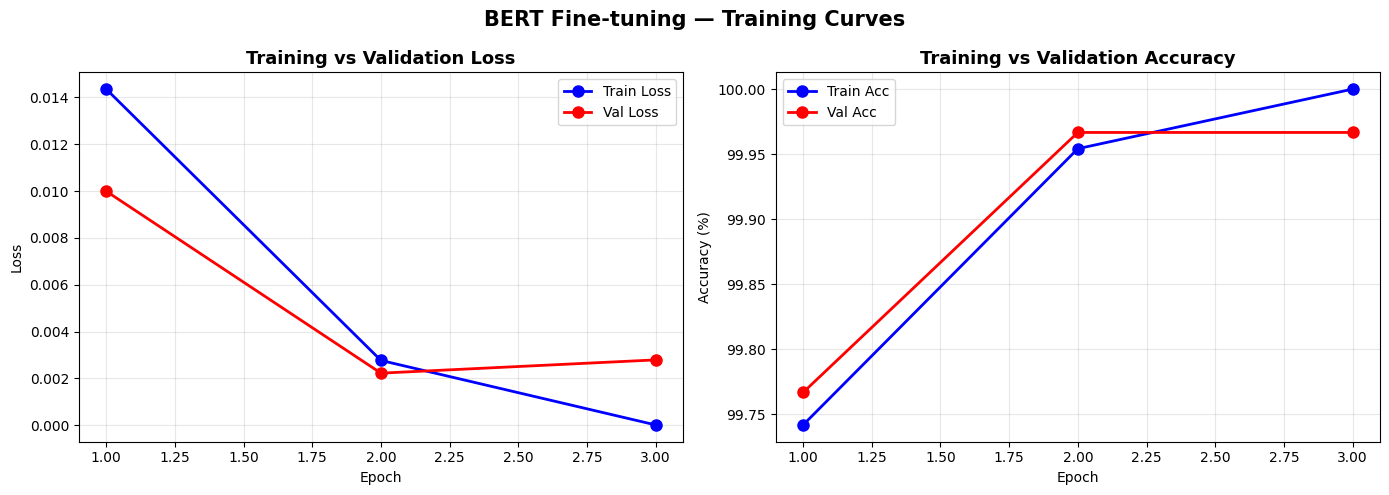

Training curves saved to Drive!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'],
             'bo-', label='Train Loss', linewidth=2, markersize=8)
axes[0].plot(epochs_range, history['val_loss'],
             'ro-', label='Val Loss',   linewidth=2, markersize=8)
axes[0].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']],
             'bo-', label='Train Acc', linewidth=2, markersize=8)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],
             'ro-', label='Val Acc',   linewidth=2, markersize=8)
axes[1].set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('BERT Fine-tuning — Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAPHS_SAVE_PATH}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved to Drive!")

In [ ]:
print("Evaluating on Test Set...")
test_loss, test_acc, test_preds, test_labels = eval_epoch(
    model, test_loader, device)

# Metrics
accuracy  = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall    = recall_score(test_labels, test_preds)
f1        = f1_score(test_labels, test_preds)

print("\n" + "=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print("=" * 50)
print("\n Full Classification Report:")
print(classification_report(test_labels, test_preds,
                             target_names=['Real', 'Fake']))

Evaluating on Test Set...

FINAL TEST RESULTS
  Accuracy  : 99.93%
  Precision : 99.94%
  Recall    : 99.94%
  F1-Score  : 99.94%

 Full Classification Report:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      1434
        Fake       1.00      1.00      1.00      1566

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



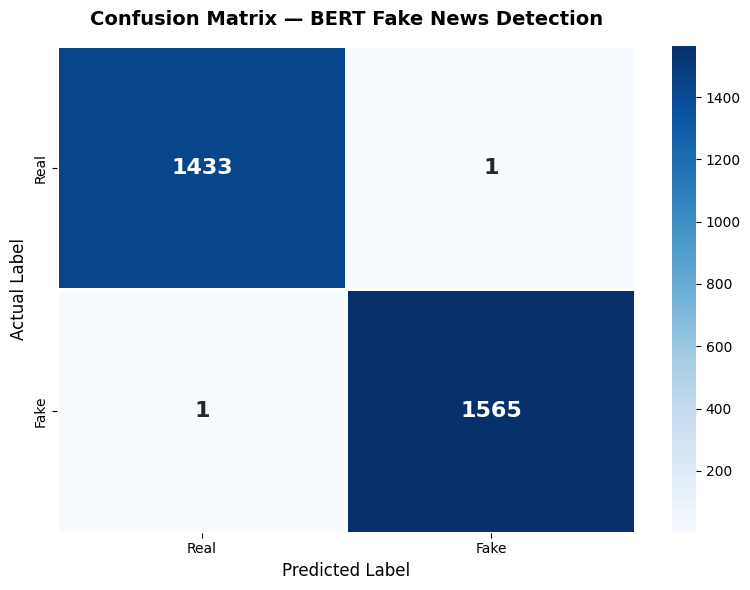

Confusion matrix saved to Drive!


In [ ]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'],
            linewidths=2, linecolor='white',
            annot_kws={"size": 16, "weight": "bold"})

plt.title('Confusion Matrix — BERT Fake News Detection',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Label',    fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(f"{GRAPHS_SAVE_PATH}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to Drive!")

In [ ]:
print("Saving BERT model to Google Drive...")

model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

print(f"Model saved successfully!")
print(f"   Location: {MODEL_SAVE_PATH}")
print(f"\n Saved files:")
for f in os.listdir(MODEL_SAVE_PATH):
    size = os.path.getsize(os.path.join(MODEL_SAVE_PATH, f)) / (1024*1024)
    print(f"   {f}  ({size:.1f} MB)")

Saving BERT model to Google Drive...
Model saved successfully!
   Location: /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/bert_model

 Saved files:
   config.json  (0.0 MB)
   model.safetensors  (417.7 MB)
   tokenizer_config.json  (0.0 MB)
   special_tokens_map.json  (0.0 MB)
   vocab.txt  (0.2 MB)


In [ ]:
def predict_news(text, model, tokenizer, device, max_len=128):
    """Predict whether a news article is Fake or Real."""
    model.eval()

    # Clean the text
    cleaned = clean_text(text)

    # Tokenize
    encoding = tokenizer(
        cleaned,
        max_length     = max_len,
        truncation     = True,
        padding        = 'max_length',
        return_tensors = 'pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        probs   = torch.softmax(logits, dim=1)
        pred    = torch.argmax(probs, dim=1).item()

    label      = "FAKE" if pred == 1 else "REAL"
    confidence = probs[0][pred].item() * 100

    return label, confidence

# ── Test with examples ──────────────────────────────
test_examples = [
    "NASA confirms humans landed on the moon in 1969 during the Apollo mission.",
    "Scientists discover that drinking bleach cures all diseases instantly.",
    "The President signed a new infrastructure bill worth 1.2 trillion dollars.",
    "Aliens have taken over the White House and nobody is reporting it."
]

print("Inference Test Results:")
print("=" * 65)
for text in test_examples:
    label, conf = predict_news(text, model, tokenizer, device)
    print(f"\n Text      : {text[:70]}...")
    print(f"   Prediction: {label}  (Confidence: {conf:.1f}%)")
print("=" * 65)

Inference Test Results:

 Text      : NASA confirms humans landed on the moon in 1969 during the Apollo miss...
   Prediction: FAKE  (Confidence: 98.9%)

 Text      : Scientists discover that drinking bleach cures all diseases instantly....
   Prediction: FAKE  (Confidence: 100.0%)

 Text      : The President signed a new infrastructure bill worth 1.2 trillion doll...
   Prediction: FAKE  (Confidence: 100.0%)

 Text      : Aliens have taken over the White House and nobody is reporting it....
   Prediction: FAKE  (Confidence: 100.0%)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_PATH        = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"
FAKE_CSV         = os.path.join(BASE_PATH, "datasets/fake_news/Fake.csv")
TRUE_CSV         = os.path.join(BASE_PATH, "datasets/fake_news/True.csv")
MODEL_SAVE_PATH  = os.path.join(BASE_PATH, "models/bert_model")
GRAPHS_SAVE_PATH = os.path.join(BASE_PATH, "outputs/graphs")

print("Paths restored!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths restored!


In [ ]:
!pip install -q transformers==4.35.0
print("Libraries ready!")

Libraries ready!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import nltk, re, string, warnings
from nltk.corpus import stopwords
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" All imports done!")
print(f" Device: {device}")

 All imports done!
 Device: cuda


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Loading CSVs...")
fake_df = pd.read_csv(FAKE_CSV)
true_df = pd.read_csv(TRUE_CSV)

fake_df['label']   = 1
true_df['label']   = 0
fake_df['content'] = fake_df['title'].fillna('') + ' ' + fake_df['text'].fillna('')
true_df['content'] = true_df['title'].fillna('') + ' ' + true_df['text'].fillna('')

df = pd.concat([fake_df[['content','label']],
                true_df[['content','label']]], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df[df['content'].str.strip() != ''].reset_index(drop=True)

print(f"Dataset rebuilt!")
print(f"   Total rows : {len(df):,}")
print(f"   Fake rows  : {(df['label']==1).sum():,}")
print(f"   Real rows  : {(df['label']==0).sum():,}")

Loading CSVs...
Dataset rebuilt!
   Total rows : 44,898
   Fake rows  : 23,481
   Real rows  : 21,417


In [ ]:
print(" Loading saved BERT model from Drive...")

model     = BertForSequenceClassification.from_pretrained(MODEL_SAVE_PATH)
tokenizer = BertTokenizer.from_pretrained(MODEL_SAVE_PATH)
model     = model.to(device)
model.eval()

print(f"Model loaded from Drive!")
print(f"   Location : {MODEL_SAVE_PATH}")
print(f"   Device   : {device}")

 Loading saved BERT model from Drive...
Model loaded from Drive!
   Location : /content/drive/MyDrive/AI_FakeNews_Deepfake_Project/models/bert_model
   Device   : cuda


In [ ]:
def predict_news(text, model, tokenizer, device, max_len=128):
    """
    Fixed inference — uses raw text, not aggressively cleaned text.
    BERT handles its own tokenization internally.
    """
    model.eval()
    clean = text.lower().strip()

    encoding = tokenizer(
        clean,
        max_length     = max_len,
        truncation     = True,
        padding        = 'max_length',
        return_tensors = 'pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)

    pred      = torch.argmax(probs, dim=1).item()
    label     = "FAKE" if pred == 1 else " REAL"
    conf_real = probs[0][0].item() * 100
    conf_fake = probs[0][1].item() * 100

    return label, conf_real, conf_fake


test_examples = [
    "NASA confirms humans landed on the moon in 1969 during the Apollo mission.",
    "Scientists discover that drinking bleach cures all diseases instantly.",
    "The President signed a new infrastructure bill worth 1.2 trillion dollars.",
    "Aliens have taken over the White House and nobody is reporting it.",
    "The stock market rose 2% today following strong jobs report data.",
    "Government puts microchips in COVID vaccines to track citizens secretly.",
]

print(" Inference Results:")
print("=" * 70)
for text in test_examples:
    label, conf_real, conf_fake = predict_news(text, model, tokenizer, device)
    print(f"\n{text[:72]}")
    print(f"   → {label}")
    print(f"      Real: {conf_real:.1f}%  |  Fake: {conf_fake:.1f}%")
print("=" * 70)

 Inference Results:

NASA confirms humans landed on the moon in 1969 during the Apollo missio
   →  REAL
      Real: 52.4%  |  Fake: 47.6%

Scientists discover that drinking bleach cures all diseases instantly.
   → FAKE
      Real: 0.3%  |  Fake: 99.7%

The President signed a new infrastructure bill worth 1.2 trillion dollar
   →  REAL
      Real: 61.3%  |  Fake: 38.7%

Aliens have taken over the White House and nobody is reporting it.
   → FAKE
      Real: 2.3%  |  Fake: 97.7%

The stock market rose 2% today following strong jobs report data.
   → FAKE
      Real: 0.1%  |  Fake: 99.9%

Government puts microchips in COVID vaccines to track citizens secretly.
   → FAKE
      Real: 0.0%  |  Fake: 100.0%


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

# ── Config ──────────────────────────────────────────
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 3

# ── KEY FIX: Use raw lowercased text, NOT aggressively cleaned text ──
# BERT was pretrained on natural language — it needs full sentences
df_sample = df.sample(n=30000, random_state=42).reset_index(drop=True)

X = df_sample['content'].str.lower().str.strip().values
y = df_sample['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f" Data split complete!")
print(f"   Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"\n Sample RAW text (what BERT now sees):")
print(f"   '{X_train[0][:150]}...'")

✅ Data split complete!
   Train: 24,000 | Val: 3,000 | Test: 3,000

📝 Sample RAW text (what BERT now sees):
   'immigrants in limbo as u.s. top court weighs obama action baltimore (reuters) - in the port city of baltimore, where europeans once streamed into amer...'


In [ ]:
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length     = self.max_len,
            truncation     = True,
            padding        = 'max_length',
            return_tensors = 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create Datasets
train_dataset = FakeNewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = FakeNewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = FakeNewsDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders ready!")
print(f"   Train batches: {len(train_loader):,}")
print(f"   Val batches  : {len(val_loader):,}")
print(f"   Test batches : {len(test_loader):,}")

✅ DataLoaders ready!
   Train batches: 1,500
   Val batches  : 188
   Test batches : 188


In [ ]:
# ── Class weights (handles any imbalance) ──────────────────
class_weights = compute_class_weight(
    'balanced', classes=np.array([0, 1]), y=y_train)
class_weights_tensor = torch.tensor(
    class_weights, dtype=torch.float).to(device)

print(f"⚖️  Class weights:")
print(f"   Real (0): {class_weights[0]:.4f}")
print(f"   Fake (1): {class_weights[1]:.4f}")

# ── Fresh BERT model ────────────────────────────────────────
print("\n⏳ Loading fresh BERT model...")
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels           = 2,
    hidden_dropout_prob  = 0.2,      # slight regularization
    attention_probs_dropout_prob = 0.2
)
model = model.to(device)

# ── Optimizer + Scheduler ───────────────────────────────────
optimizer    = AdamW(model.parameters(), lr=2e-5, eps=1e-8, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = int(0.1 * total_steps),   # 10% warmup
    num_training_steps = total_steps
)

# ── Weighted cross-entropy loss ─────────────────────────────
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"✅ Model, optimizer, scheduler ready!")
print(f"   Total training steps : {total_steps:,}")
print(f"   Warmup steps         : {int(0.1 * total_steps):,}")

⚖️  Class weights:
   Real (0): 1.0467
   Fake (1): 0.9573

⏳ Loading fresh BERT model...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model, optimizer, scheduler ready!
   Total training steps : 4,500
   Warmup steps         : 450


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = torch.argmax(outputs.logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (batch_idx + 1) % 200 == 0:
            print(f"   Step {batch_idx+1:>4}/{len(loader)} | "
                  f"Loss: {loss.item():.4f} | "
                  f"Acc: {correct/total*100:.2f}%")

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels      = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs    = model(input_ids=input_ids, attention_mask=attention_mask)
            loss       = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            preds       = torch.argmax(outputs.logits, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


# ── Run Training ────────────────────────────────────────────
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc  = 0
best_model_state = None

print("🚀 Starting Retrain — BERT on Raw Text + Weighted Loss")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"\n📌 Epoch {epoch+1}/{EPOCHS}")
    print("-" * 45)

    t_loss, t_acc = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, device)
    v_loss, v_acc, v_preds, v_labels = eval_epoch(
        model, val_loader, device)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    # Save best model state in memory
    if v_acc > best_val_acc:
        best_val_acc     = v_acc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"   💾 New best model! Val Acc: {v_acc*100:.2f}%")

    print(f"\n   📊 Epoch {epoch+1} Summary")
    print(f"      Train → Loss: {t_loss:.4f} | Acc: {t_acc*100:.2f}%")
    print(f"      Val   → Loss: {v_loss:.4f} | Acc: {v_acc*100:.2f}%")
    print(f"      Val Precision: {precision_score(v_labels, v_preds)*100:.2f}%  "
          f"Recall: {recall_score(v_labels, v_preds)*100:.2f}%  "
          f"F1: {f1_score(v_labels, v_preds)*100:.2f}%")

print(f"\n🎉 Training Complete! Best Val Acc: {best_val_acc*100:.2f}%")

# Restore best model weights
model.load_state_dict(best_model_state)
print("✅ Best model weights restored!")

🚀 Starting Retrain — BERT on Raw Text + Weighted Loss


NameError: name 'EPOCHS' is not defined

LIAR DATASET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, re, string, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import nltk
from nltk.corpus import stopwords
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

BASE_PATH        = "/content/drive/MyDrive/AI_FakeNews_Deepfake_Project"
FAKE_CSV         = os.path.join(BASE_PATH, "datasets/fake_news/Fake.csv")
TRUE_CSV         = os.path.join(BASE_PATH, "datasets/fake_news/True.csv")
MODEL_SAVE_PATH  = os.path.join(BASE_PATH, "models/bert_model")
GRAPHS_SAVE_PATH = os.path.join(BASE_PATH, "outputs/graphs")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Done! Device: {device}")

✅ Done! Device: cuda


In [ ]:
!pip install -q transformers==4.35.0

print("⏳ Loading saved model from Drive...")
model     = BertForSequenceClassification.from_pretrained(MODEL_SAVE_PATH)
tokenizer = BertTokenizer.from_pretrained(MODEL_SAVE_PATH)
model     = model.to(device)
model.eval()
print("✅ Model loaded! Ready to use.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 28.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.17.3 which is incompatible.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.17.3 which is incompatible.
sentence-transformers 5.5.1 requires huggingface-hub>=0.23.0, but you have huggingface-hub 0.17.3 which is incompatible.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.35.0 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model loaded! Ready to use.


In [ ]:
from sklearn.model_selection import train_test_split

print("⏳ Rebuilding dataset...")
fake_df = pd.read_csv(FAKE_CSV)
true_df = pd.read_csv(TRUE_CSV)

fake_df['label']   = 1
true_df['label']   = 0
fake_df['content'] = fake_df['title'].fillna('') + ' ' + fake_df['text'].fillna('')
true_df['content'] = true_df['title'].fillna('') + ' ' + true_df['text'].fillna('')

df = pd.concat([fake_df[['content','label']],
                true_df[['content','label']]])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df[df['content'].str.strip() != ''].reset_index(drop=True)

# Rebuild exact same test split (random_state=42 guarantees same split)
df_sample = df.sample(n=30000, random_state=42).reset_index(drop=True)
X = df_sample['content'].str.lower().str.strip().values
y = df_sample['label'].values

_, X_temp, _, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_test, _, y_test, _ = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"✅ Test set rebuilt: {len(X_test):,} rows")
print(f"   Fake: {y_test.sum():,} | Real: {(y_test==0).sum():,}")

⏳ Rebuilding dataset...
✅ Test set rebuilt: 3,000 rows
   Fake: 1,567 | Real: 1,433


🔍 Evaluating on Test Set...

  📊 FINAL TEST RESULTS
  Accuracy  : 99.13%
  Precision : 99.94%
  Recall    : 98.40%
  F1-Score  : 99.16%

📋 Classification Report:
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99      1433
        Fake       1.00      0.98      0.99      1567

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



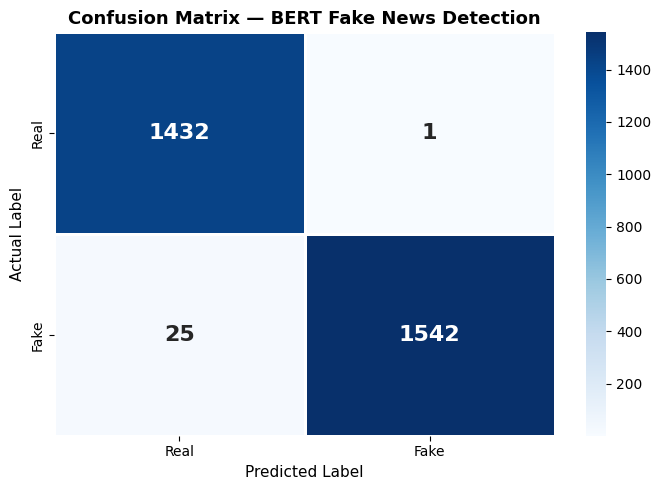

✅ Confusion matrix saved!

🧪 Inference Test:

📰 NASA confirms humans landed on the moon in 1969 during the Apollo missio
   → 🔴 FAKE  |  Real: 36.1%  Fake: 63.9%

📰 Scientists discover that drinking bleach cures all diseases instantly.
   → 🔴 FAKE  |  Real: 0.2%  Fake: 99.8%

📰 The President signed a new infrastructure bill worth 1.2 trillion dollar
   → 🟢 REAL  |  Real: 88.3%  Fake: 11.7%

📰 Aliens have taken over the White House and nobody is reporting it.
   → 🔴 FAKE  |  Real: 0.1%  Fake: 99.9%

📰 The stock market rose 2% today following strong jobs report data.
   → 🔴 FAKE  |  Real: 0.0%  Fake: 100.0%

📰 Government puts microchips in COVID vaccines to track citizens secretly.
   → 🔴 FAKE  |  Real: 0.0%  Fake: 100.0%


In [ ]:
# ── Dataset + DataLoader ────────────────────────────
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]), max_length=self.max_len,
            truncation=True, padding='max_length', return_tensors='pt')
        return {'input_ids'     : enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'label'         : torch.tensor(self.labels[idx], dtype=torch.long)}

test_loader = DataLoader(
    FakeNewsDataset(X_test, y_test, tokenizer, 128),
    batch_size=16, shuffle=False)

# ── Evaluation ──────────────────────────────────────
def eval_model(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs        = model(input_ids=input_ids,
                                   attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

print("🔍 Evaluating on Test Set...")
test_preds, test_labels = eval_model(model, test_loader, device)

# ── Metrics ─────────────────────────────────────────
acc  = accuracy_score(test_labels,  test_preds)
prec = precision_score(test_labels, test_preds)
rec  = recall_score(test_labels,    test_preds)
f1   = f1_score(test_labels,        test_preds)

print(f"\n{'='*50}")
print(f"  📊 FINAL TEST RESULTS")
print(f"{'='*50}")
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"{'='*50}")
print(f"\n📋 Classification Report:")
print(classification_report(test_labels, test_preds,
                             target_names=['Real','Fake']))

# ── Confusion Matrix ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real','Fake'],
            yticklabels=['Real','Fake'],
            linewidths=2, linecolor='white',
            annot_kws={"size":16,"weight":"bold"}, ax=ax)
ax.set_title('Confusion Matrix — BERT Fake News Detection',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label',    fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig(f"{GRAPHS_SAVE_PATH}/confusion_matrix_final.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

# ── Inference Test ──────────────────────────────────
def predict_news(text, model, tokenizer, device, max_len=128):
    model.eval()
    enc = tokenizer(text.lower().strip(), max_length=max_len,
                    truncation=True, padding='max_length', return_tensors='pt')
    with torch.no_grad():
        probs = torch.softmax(
            model(input_ids=enc['input_ids'].to(device),
                  attention_mask=enc['attention_mask'].to(device)).logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    return ("🔴 FAKE" if pred==1 else "🟢 REAL",
            probs[0][0].item()*100, probs[0][1].item()*100)

examples = [
    "NASA confirms humans landed on the moon in 1969 during the Apollo mission.",
    "Scientists discover that drinking bleach cures all diseases instantly.",
    "The President signed a new infrastructure bill worth 1.2 trillion dollars.",
    "Aliens have taken over the White House and nobody is reporting it.",
    "The stock market rose 2% today following strong jobs report data.",
    "Government puts microchips in COVID vaccines to track citizens secretly.",
]

print("\n🧪 Inference Test:")
print("=" * 70)
for text in examples:
    label, conf_real, conf_fake = predict_news(text, model, tokenizer, device)
    print(f"\n📰 {text[:72]}")
    print(f"   → {label}  |  Real: {conf_real:.1f}%  Fake: {conf_fake:.1f}%")
print("=" * 70)

In [ ]:
my_articles = [
  """Greetings from _Cognisoft Technologies_!

We are pleased to inform you that your profile has been shortlisted for the _Data Entry Internship_ with us.

Your Internshala profile indicates that you are available for immediate joining. As this is an urgent requirement, we have shortlisted your profile for a walk-in interview scheduled _tomorrow_.

_Job Description: Data Entry Intern_
_Key Responsibilities:_
- Collect, clean, and analyze large datasets to identify trends and insights
- Assist the team in data-driven decision making and business analysis
- Work with cross-functional teams to support ongoing projects
- Maintain data accuracy and ensure timely reporting

_Requirements:_
Intermediated, - Pursuing/Graduate in B.Tech, BCA, B.Sc IT, Statistics, or related field
- Knowledge of Excel, SQL, and basic Python/R preferred
- Strong analytical and problem-solving skills
- Available for immediate joining
- Duration: 3-6 months internship

_Stipend & Working Hours:_
- _Part-time:_ ₹18,000 per month | Flexible working hours: 3-4 hrs/day
- _Full-time:_ ₹25,000 per month | Working hours: 7-8 hrs/day

Salary is commensurate with experience

_Post-Selection Benefits:_
- _Internship Certificate_ will be provided by the company upon successful completion
- _Placement Assistance_: Top performers will be considered for full-time placement opportunities
- _Remote Work Offer Letter_ will be issued to candidates selected for remote roles

_Interview Details:_
- _Date:_ 23rd may,2026 (Saturday)
- Reporting _Time:_ 9:30 AM to 12:00 PM
- _Venue:_ 6th Floor, The Business Park - By Pranava Group, Kothaguda, Hyderabad, Telangana 500084
  Location:   https://maps.app.goo.gl/HWtrwj8B8ShVcbVh9?g_st=aw
- _Nearest Metro:_ HI-TECH CITY

_Documents to Carry:_
1. Two passport-size photographs
2. Aadhaar Card (Xerox copy)
3. Updated Resume  Copy

Kindly confirm your availability for the walk-in interview by replying to this mail or contacting _Lalitha at 9217859655 at WhatsApp _.

We look forward to meeting you.

_Best regards,_
_HR Team_
_COGNISOFT TECHNOLOGIES_ """
]


def predict_news(text, model, tokenizer, device, max_len=128):
    model.eval()
    enc = tokenizer(
        text.lower().strip(),
        max_length=max_len, truncation=True,
        padding='max_length', return_tensors='pt'
    )
    with torch.no_grad():
        probs = torch.softmax(
            model(
                input_ids=enc['input_ids'].to(device),
                attention_mask=enc['attention_mask'].to(device)
            ).logits, dim=1
        )
    pred = torch.argmax(probs, dim=1).item()
    return (
        "🔴 FAKE" if pred == 1 else "🟢 REAL",
        probs[0][0].item() * 100,
        probs[0][1].item() * 100
    )

print("=" * 65)
print("        🔍 FAKE NEWS DETECTION RESULTS")
print("=" * 65)

for i, article in enumerate(my_articles, 1):
    label, conf_real, conf_fake = predict_news(
        article, model, tokenizer, device)
    print(f"\n[{i}] {article[:80]}...")
    print(f"     Prediction : {label}")
    print(f"     Real       : {conf_real:.1f}%  |  Fake: {conf_fake:.1f}%")
    print(f"     Confidence : {'HIGH' if max(conf_real, conf_fake) > 85 else 'MODERATE'}")
    print("-" * 65)

print("\n✅ Done!")

        🔍 FAKE NEWS DETECTION RESULTS

[1] Greetings from _Cognisoft Technologies_!

We are pleased to inform you that your...
     Prediction : 🔴 FAKE
     Real       : 0.5%  |  Fake: 99.5%
     Confidence : HIGH
-----------------------------------------------------------------

✅ Done!


In [ ]:
my_articles = [
    # 1
    "The United States Federal Reserve raised interest rates by 25 basis points on Wednesday, marking the tenth consecutive increase as the central bank continues its fight against inflation that has plagued the economy since 2021.",

    # 2
    "NASA scientists have confirmed that the moon is slowly moving away from Earth at a rate of approximately 3.8 centimeters per year, a phenomenon that has been measured using laser ranging experiments since the Apollo missions.",

    # 3
    "SHOCKING: Bill Gates admits in secret video that COVID-19 vaccines contain live microchips that activate via 5G towers to monitor and control the global population, leaked documents from WHO confirm.",

    # 4
    "The Indian Space Research Organisation successfully launched its PSLV-C55 rocket carrying two Singapore satellites from the Satish Dhawan Space Centre in Sriharikota on Monday morning.",

    # 5
    "Scientists at MIT have PROVEN that drinking a mixture of turmeric, lemon, and baking soda every morning for 7 days will completely cure diabetes, cancer, and heart disease — doctors are trying to hide this miracle cure!",

    # 6
    "The European Central Bank announced a package of economic measures aimed at stabilising inflation across the eurozone, with policymakers citing concerns over energy prices and supply chain disruptions.",

    # 7
    "URGENT: The government has secretly passed a law that allows them to seize all private bank accounts above 10 lakh rupees starting next month — share this before it gets deleted!",

    # 8
    "Apple Inc reported quarterly revenue of 94.8 billion dollars, missing analyst expectations slightly, as iPhone sales in China declined amid increasing competition from local smartphone manufacturers.",

    # 9
    "A new study published in the journal Nature found that regular physical exercise of at least 150 minutes per week is associated with a 35 percent reduction in the risk of developing type 2 diabetes.",

    # 10
    "EXPOSED: The Eiffel Tower in Paris is actually a giant antenna built by the Illuminati in 1889 to transmit mind-control frequencies — the French government has been covering this up for over 100 years!",
]

# ── Do not edit below this line ──────────────────────────────

def predict_news(text, model, tokenizer, device, max_len=128):
    model.eval()
    enc = tokenizer(
        text.lower().strip(),
        max_length=max_len, truncation=True,
        padding='max_length', return_tensors='pt'
    )
    with torch.no_grad():
        probs = torch.softmax(
            model(
                input_ids=enc['input_ids'].to(device),
                attention_mask=enc['attention_mask'].to(device)
            ).logits, dim=1
        )
    pred = torch.argmax(probs, dim=1).item()
    return (
        "🔴 FAKE" if pred == 1 else "🟢 REAL",
        probs[0][0].item() * 100,
        probs[0][1].item() * 100
    )

print("=" * 65)
print("        🔍 FAKE NEWS DETECTION RESULTS")
print("=" * 65)

for i, article in enumerate(my_articles, 1):
    label, conf_real, conf_fake = predict_news(
        article, model, tokenizer, device)
    print(f"\n[{i}] {article[:70]}...")
    print(f"     Prediction : {label}")
    print(f"     Real       : {conf_real:.1f}%  |  Fake: {conf_fake:.1f}%")
    print(f"     Confidence : {'HIGH' if max(conf_real, conf_fake) > 85 else 'MODERATE'}")
    print("-" * 65)

print("\n✅ Done!")

        🔍 FAKE NEWS DETECTION RESULTS

[1] The United States Federal Reserve raised interest rates by 25 basis po...
     Prediction : 🟢 REAL
     Real       : 97.1%  |  Fake: 2.9%
     Confidence : HIGH
-----------------------------------------------------------------

[2] NASA scientists have confirmed that the moon is slowly moving away fro...
     Prediction : 🟢 REAL
     Real       : 60.4%  |  Fake: 39.6%
     Confidence : MODERATE
-----------------------------------------------------------------

[3] SHOCKING: Bill Gates admits in secret video that COVID-19 vaccines con...
     Prediction : 🔴 FAKE
     Real       : 0.0%  |  Fake: 100.0%
     Confidence : HIGH
-----------------------------------------------------------------

[4] The Indian Space Research Organisation successfully launched its PSLV-...
     Prediction : 🟢 REAL
     Real       : 96.8%  |  Fake: 3.2%
     Confidence : HIGH
-----------------------------------------------------------------

[5] Scientists at MIT have 